# Importing libraries

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Dataset 

In [115]:
df = pd.read_csv('student_dataset_10000_rows.csv')

In [116]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


# Data visualization

<Axes: ylabel='sleep_hours'>

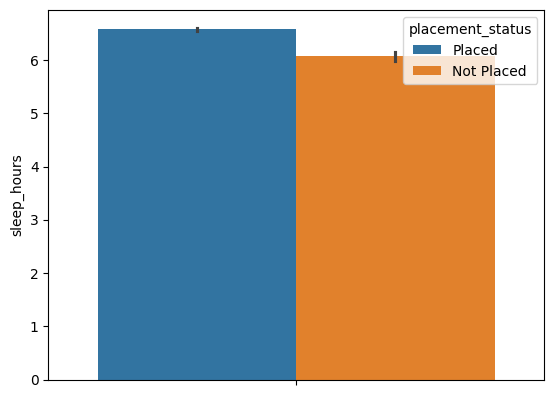

In [117]:
sns.barplot(data = df ,y ='sleep_hours',hue = 'placement_status')

<Axes: xlabel='count', ylabel='placement_status'>

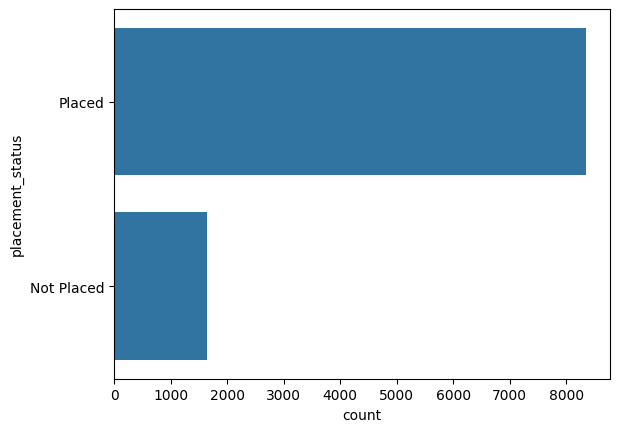

In [118]:
sns.countplot(df['placement_status'])

<Axes: >

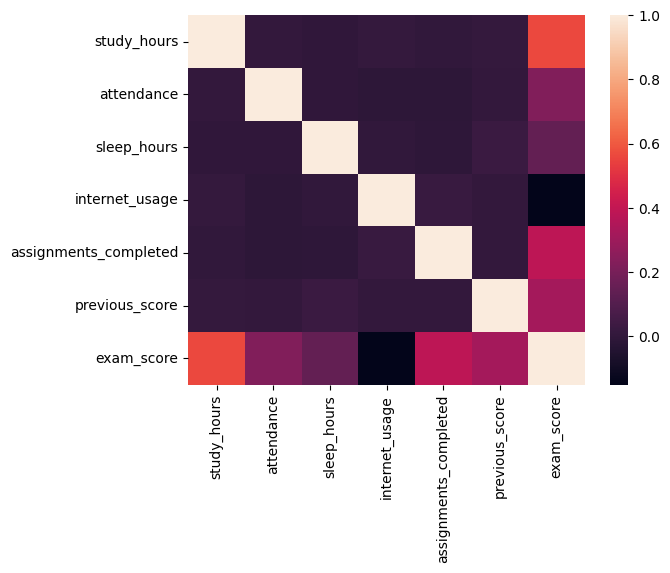

In [119]:
sns.heatmap(df.corr(numeric_only = True))

<Axes: xlabel='exam_score', ylabel='Count'>

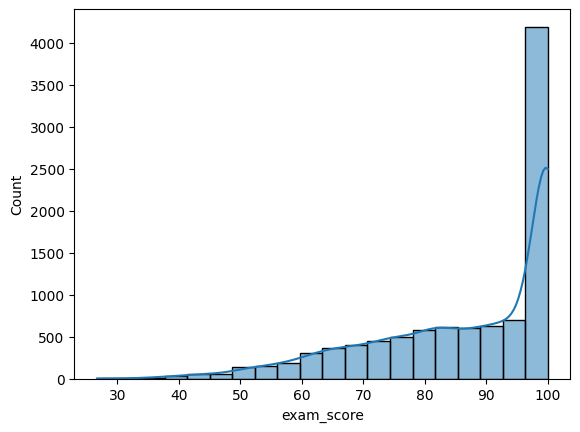

In [120]:
sns.histplot(df['exam_score'], bins=20, kde=True)


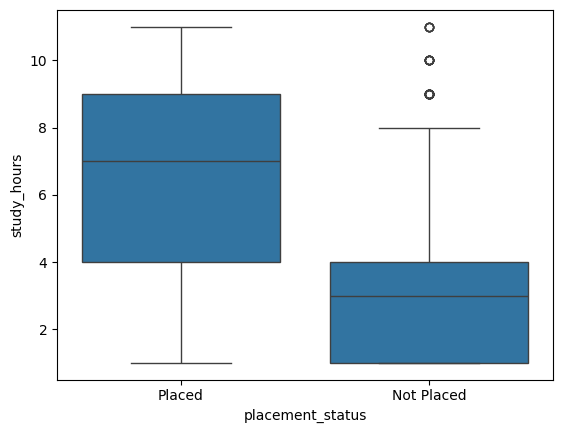

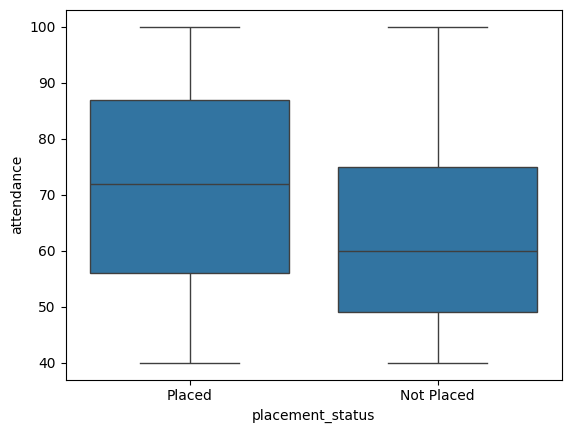

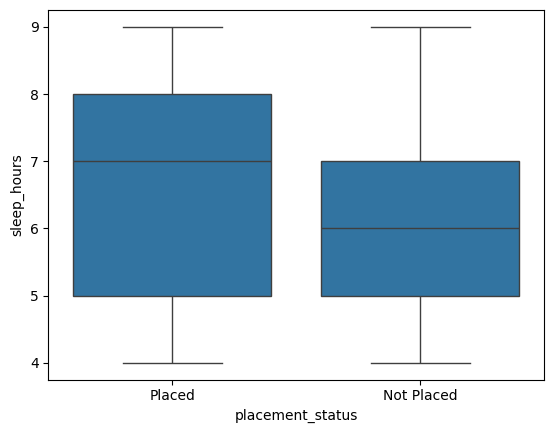

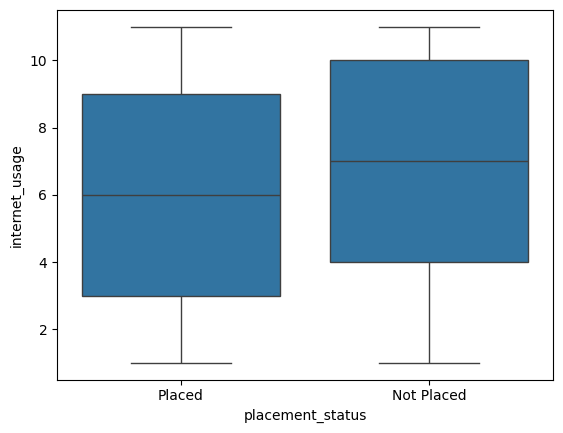

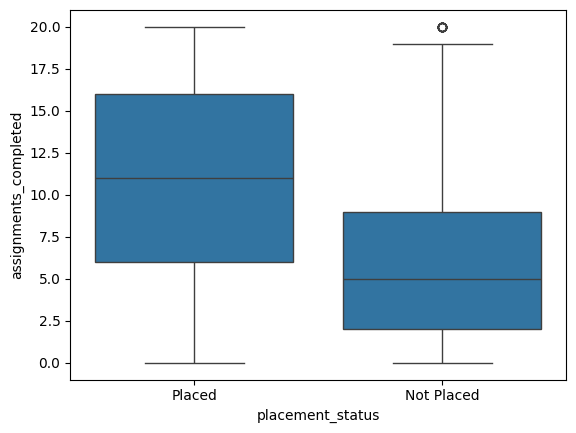

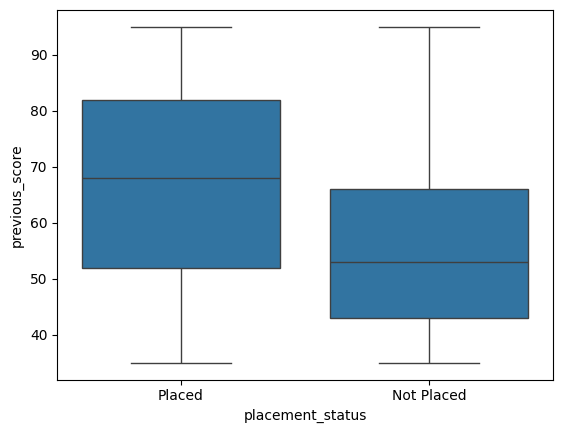

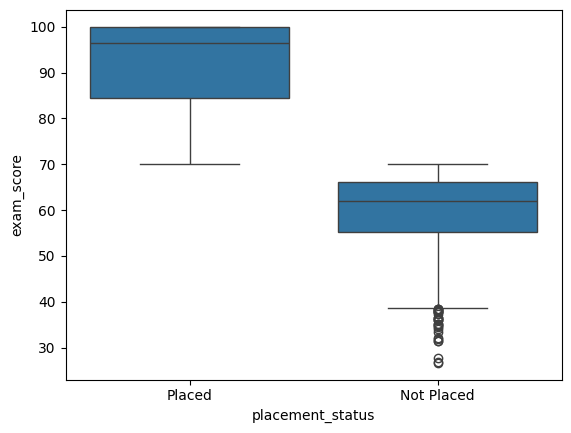

In [121]:
cols = ['study_hours','attendance',
        'sleep_hours','internet_usage',
        'assignments_completed',
        'previous_score','exam_score']

for col in cols:
    sns.boxplot(x='placement_status', y=col, data=df)
    plt.show()

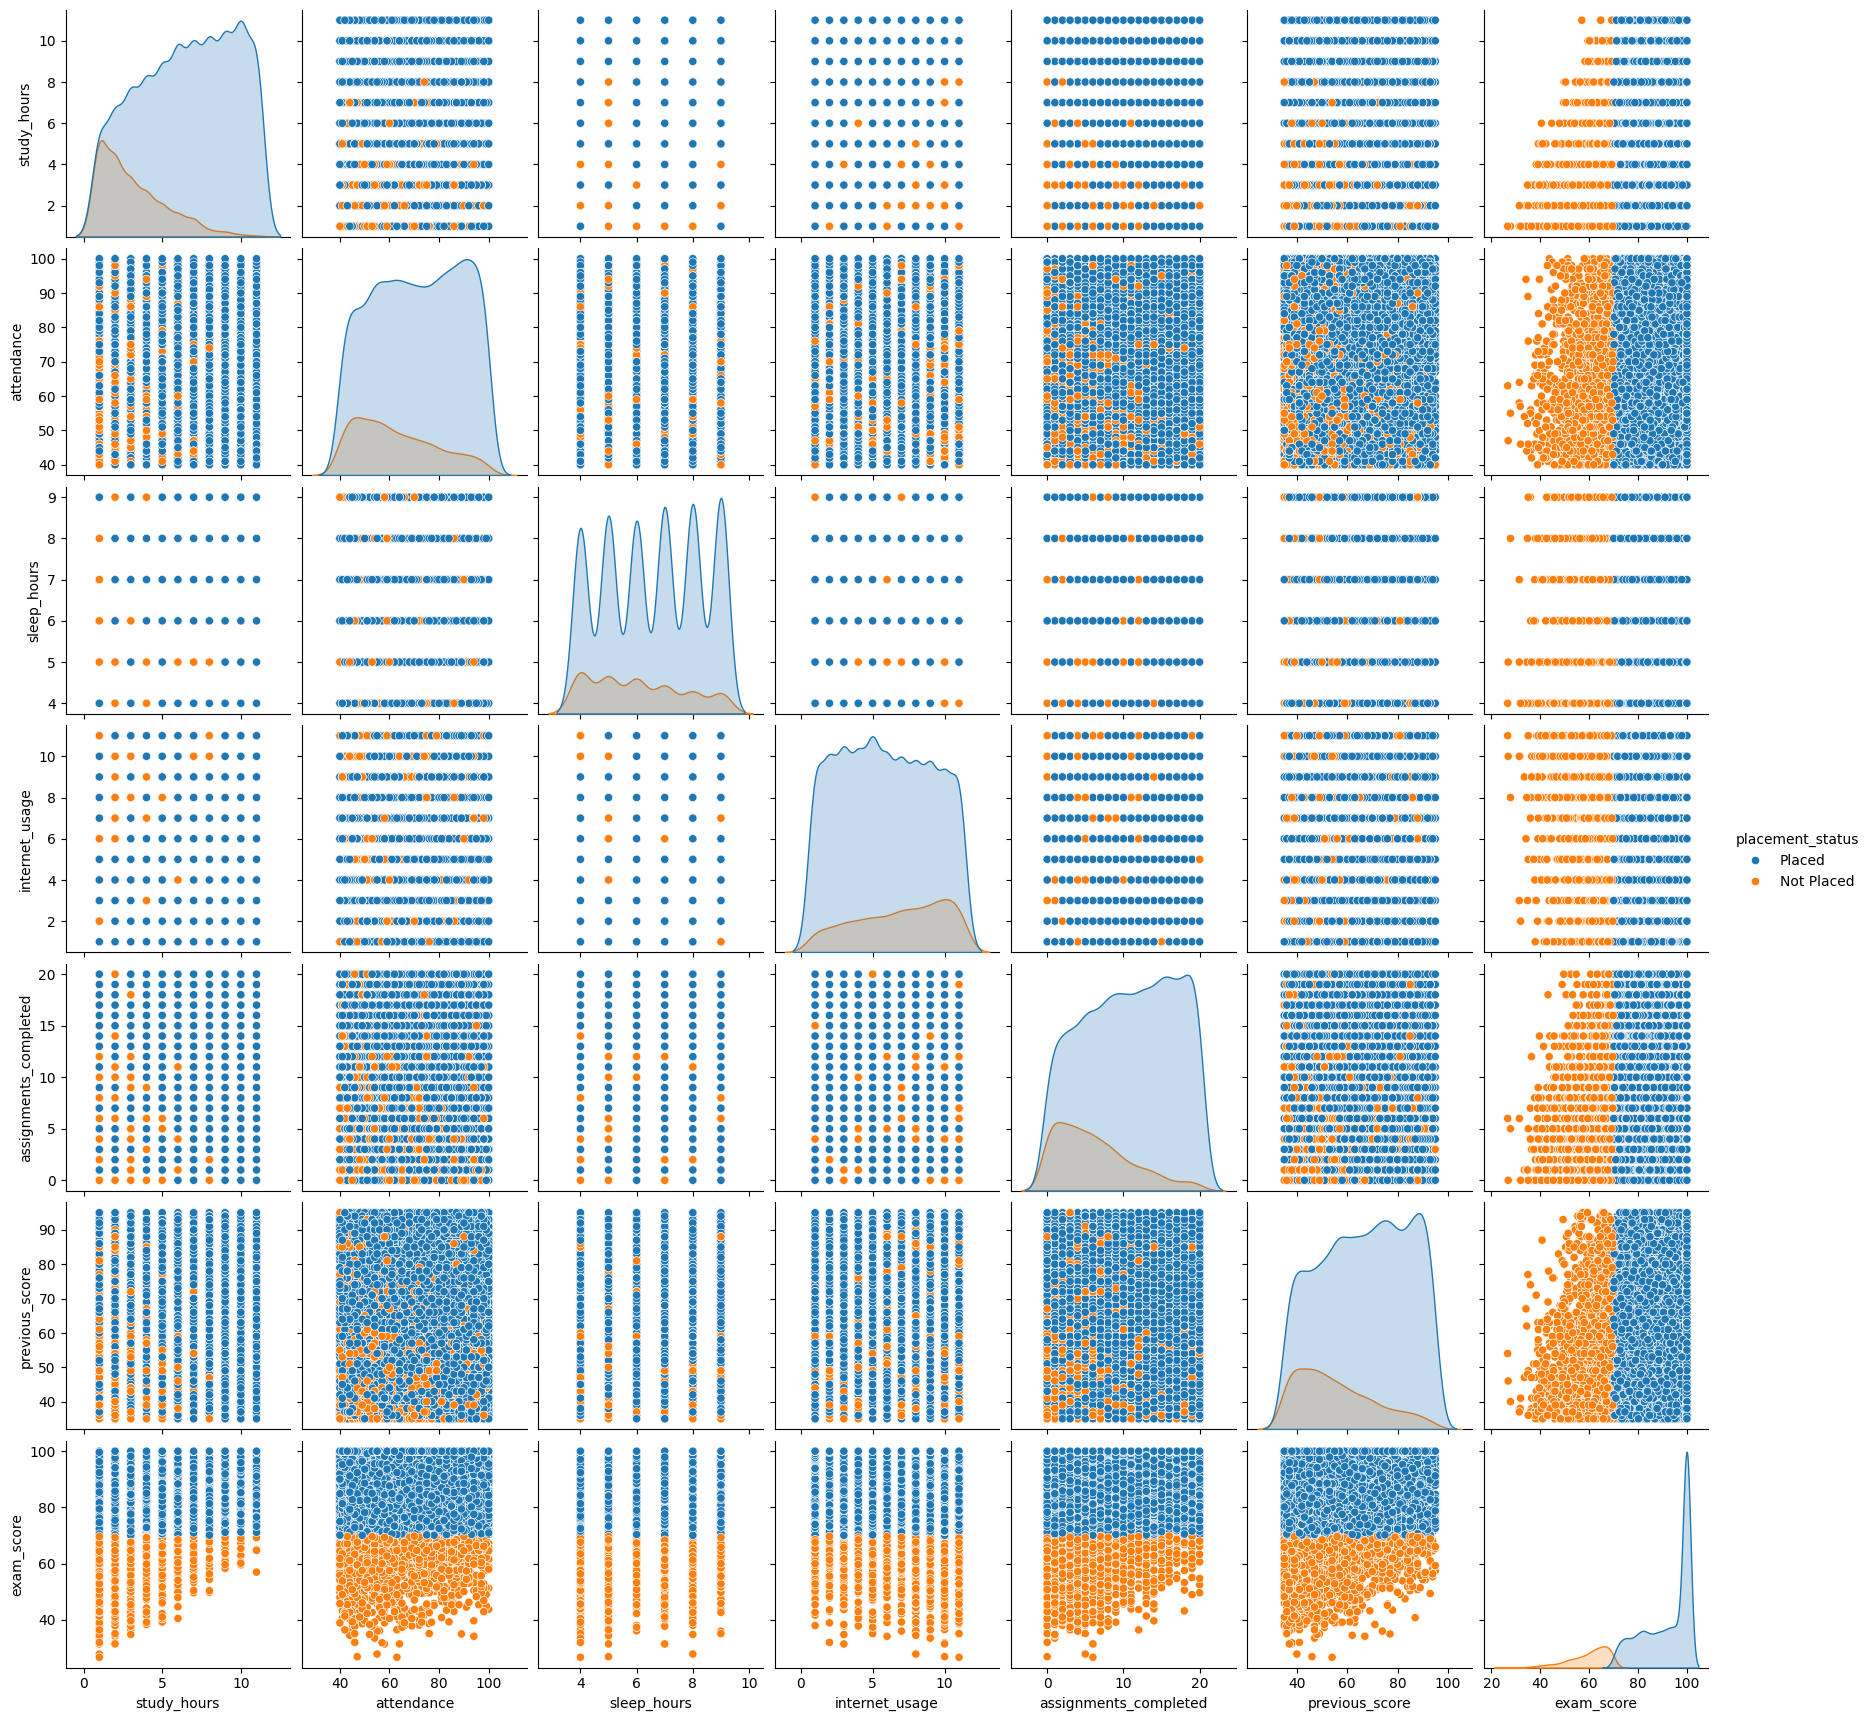

In [122]:
sns.pairplot(df,hue='placement_status')

# Data cleaning and preproccesing 

In [123]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [125]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [126]:
df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

In [127]:
df = df.drop_duplicates()

In [128]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [129]:
df['placement_status'].value_counts()

placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64

In [130]:
df['placement_status'] = df['placement_status'].map({
    'Placed': 0,
    'Not Placed': 1
})

In [131]:
df['placement_status'].value_counts()

placement_status
0    8356
1    1644
Name: count, dtype: int64

In [132]:
scaler = StandardScaler()

In [133]:
df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

In [134]:
numeric_cols = ['study_hours', 'attendance', 'sleep_hours', 'internet_usage','assignments_completed', 'previous_score', 'exam_score']

In [135]:
df[numeric_cols]=scaler.fit_transform(df[numeric_cols])

In [136]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,0.319400,-0.788197,0.878446,0.298725,0.001922,-0.166322,0.882994,0
1,-0.628937,-0.050217,-0.876691,-0.975970,-0.329541,-0.509138,0.882994,0
2,1.583850,-0.561126,0.293400,-0.019949,0.001922,-1.137632,0.882994,0
3,0.635513,1.652815,1.463492,0.617398,-0.992469,-0.566273,0.230169,0
4,-0.312825,-1.015268,0.878446,-0.019949,-0.329541,-1.423311,-0.523602,0


In [137]:
X = df.drop('placement_status',axis = 1)
y = df['placement_status']

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [139]:
models = {
    'Logical regression':LogisticRegression(),
    'SVM':SVC(),
    'Decision tree':DecisionTreeClassifier(),
    'KNN':KNeighborsClassifier(),
    'NB':GaussianNB()
}

In [140]:
result = []
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append({
        'model':name,
        'Accuracy score':round(acc,4),
        'F1 score':round(f1,4)
    })

In [141]:
result

[{'model': 'Logical regression', 'Accuracy score': 0.997, 'F1 score': 0.9911},
 {'model': 'SVM', 'Accuracy score': 0.9918, 'F1 score': 0.9759},
 {'model': 'Decision tree', 'Accuracy score': 1.0, 'F1 score': 1.0},
 {'model': 'KNN', 'Accuracy score': 0.9703, 'F1 score': 0.9107},
 {'model': 'NB', 'Accuracy score': 0.967, 'F1 score': 0.91}]

In [142]:
corr = df.corr(numeric_only=True)

corr['placement_status'].sort_values(ascending=False)

placement_status         1.000000
internet_usage           0.110233
sleep_hours             -0.110578
attendance              -0.176738
previous_score          -0.232693
assignments_completed   -0.280138
study_hours             -0.400934
exam_score              -0.792392
Name: placement_status, dtype: float64

In [143]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='f1'
    )

    print(f"{name}: {scores.mean():.4f}")

Logical regression: 0.9915
SVM: 0.9775
Decision tree: 1.0000
KNN: 0.9063
NB: 0.9062
